# ⚡ Lenz · 🌡️ Heat · 🌊 Spatial Freq · 🎨 Bezier/Delta · 🎮 pygame · 🔥 Torch 3D · 📘 Callen · 🥽 Spatial Computer

> **Brain melt edition.** Every topic is a different way of asking: *how does energy or information flow through a structure?*

| § | Topic | The deep question |
|---|---|---|
| §1 | Lenz law + heat cycles | Where does the energy go when flux changes? |
| §2 | Spatial frequency + MTF | How sharp can a system resolve a line? |
| §3 | Bezier + Dirac delta | What is a curve, really? (weighted sum of impulses) |
| §4 | Dark room OOP pygame | How do you represent a 3D world with classes? |
| §5 | Torch CUDA 3D | Point cloud · voxel · NeRF volume rendering |
| §6 | Callen + hyperbolic | Entropy, Legendre, sinh in partition sums |
| §7 | Spatial computer | Vision Pro: vergence-accommodation, display MTF |

In [1]:
import numpy as np
import sympy as sp
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Arc, Circle, Rectangle
from matplotlib.colors import LinearSegmentedColormap
from scipy.integrate import solve_ivp, odeint
from scipy.special import erf, iv as bessel_I
from scipy.ndimage import gaussian_filter
import itertools, time, warnings
warnings.filterwarnings('ignore')
sp.init_printing(use_latex='mathjax')
from IPython.display import display, Math, Markdown
# dark matplotlib style for the room aesthetic
plt.rcParams.update({
    'figure.facecolor':'#0d0d0d','axes.facecolor':'#1a1a1a',
    'axes.edgecolor':'#444','text.color':'#e0e0e0',
    'xtick.color':'#aaa','ytick.color':'#aaa',
    'axes.labelcolor':'#ccc','grid.color':'#333',
    'grid.alpha':0.5,'axes.grid':True,'figure.dpi':100,
    'lines.linewidth':2,'font.size':10,
})
np.random.seed(2026)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Torch device: {DEVICE}')
print('Dark room activated. Brain melt in progress...')

Torch device: cpu
Dark room activated. Brain melt in progress...


---
## §1 ⚡ Lenz's Law + Heat Cycles

**Faraday-Lenz:**
$\mathcal{E} = -\frac{d\Phi_B}{dt}$, $\Phi_B = \int \mathbf{B}\cdot d\mathbf{A}$

The **minus sign IS Lenz's law** — induced current opposes change.
Eddy currents → Joule heating → energy dissipated as $P = \mathcal{E}^2/R$.

**Carnot cycle:** $\eta_{max} = 1 - T_C/T_H$ (upper bound for any heat engine)

**Otto cycle (gasoline engine):** $\eta_{Otto} = 1 - r_c^{-(gamma-1)}$, $r_c$ = compression ratio

**Stirling cycle:** regenerator stores $Q_{12}$ → efficiency approaches Carnot

§1.1 Peak EMF: 869455.78 mV
     Peak current: 86945.58 mA
     Total energy dissipated: 20673615.79 uJ

§1.2 Carnot eta=0.625, Otto eta=0.565 (r_c=8)


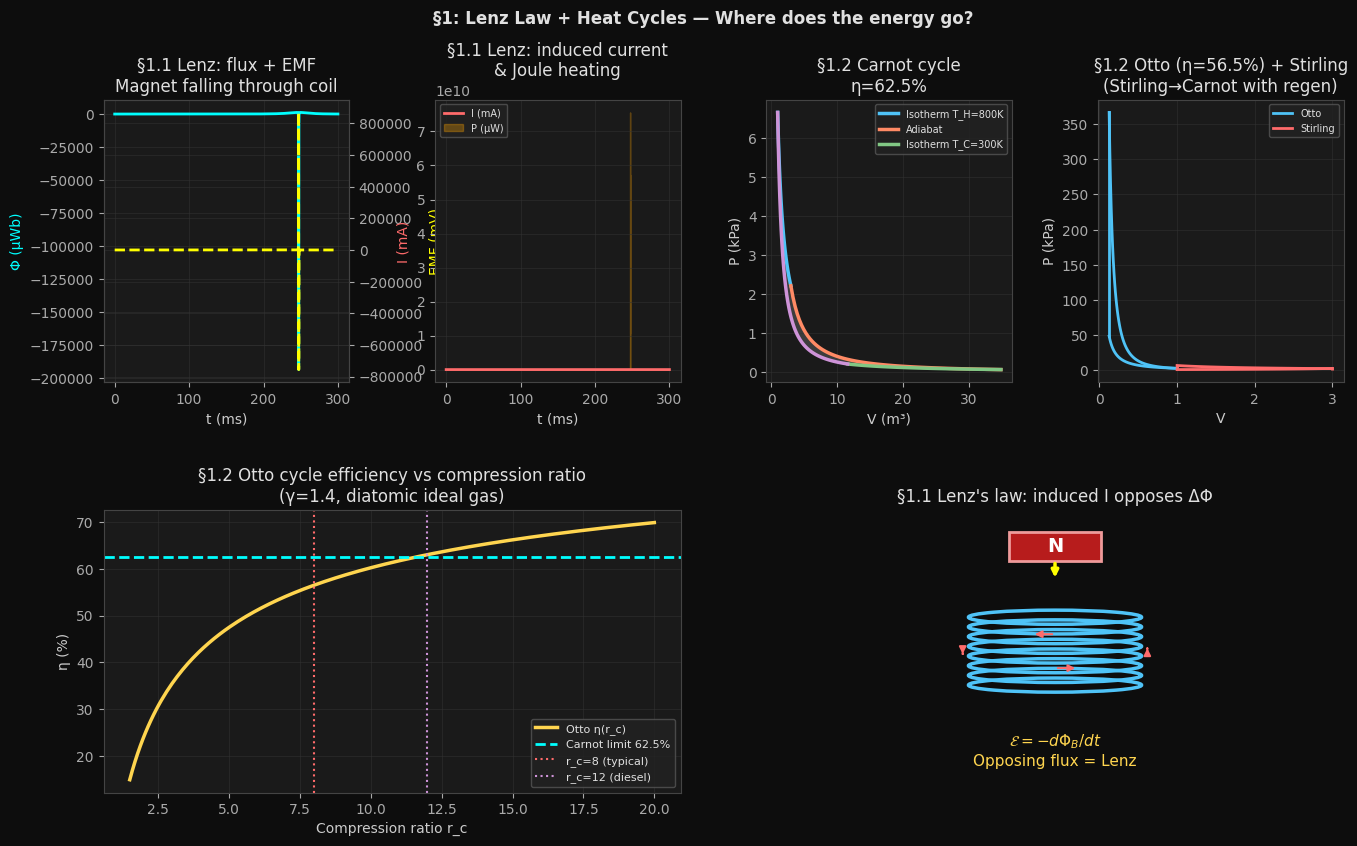

In [2]:
# §1 — Lenz's law + heat cycles

# §1.1 Faraday induction: moving magnet through coil
# B field from dipole along axis: B_z(z) = mu0/(4pi) * 2*m/(z^2+r^2)^(3/2) ... approx
mu0 = 4*np.pi*1e-7
m_dipole = 1.0   # magnetic moment A·m²
R_coil   = 0.05  # 5 cm coil radius
N_turns  = 100
R_resist = 10.0  # Ohm

def B_dipole_axis(z, m=m_dipole):
    return mu0/(2*np.pi) * m / (np.abs(z)**3 + 1e-10)

def Phi_coil(z_mag, R=R_coil, N=N_turns):
    r_arr = np.linspace(0, R, 100)
    B_arr = mu0*m_dipole*(2*(r_arr*0+z_mag)**2 - r_arr**2) / \
            (4*np.pi*(r_arr**2+z_mag**2+1e-12)**(5/2))
    return N * np.trapz(B_arr*2*np.pi*r_arr, r_arr)

# Magnet falling through coil
g = 9.81; m_mag = 0.05  # kg
def magnet_fall(t, y):
    z, v = y
    return [v, -g]   # free fall (ignore back-force for simplicity)

t_sim = np.linspace(0, 0.3, 3000)
sol   = solve_ivp(magnet_fall, [0,0.3], [0.3, 0.0], t_eval=t_sim)
z_mag = sol.y[0]; v_mag = sol.y[1]
Phi_t = np.array([Phi_coil(z) for z in z_mag])   # loop: compute flux
EMF_t = -np.gradient(Phi_t, t_sim)                # Faraday: E = -dPhi/dt
I_t   = EMF_t / R_resist
P_t   = I_t**2 * R_resist                         # Joule heating

print(f'§1.1 Peak EMF: {np.max(np.abs(EMF_t))*1000:.2f} mV')
print(f'     Peak current: {np.max(np.abs(I_t))*1000:.2f} mA')
print(f'     Total energy dissipated: {np.trapz(P_t,t_sim)*1e6:.2f} uJ')

# §1.2 Heat cycles on PV diagram
# Carnot cycle: 2 isothermals + 2 adiabats
gamma_gas = 1.4  # diatomic
T_H = 800; T_C = 300  # K
n_mol= 1.0; R_gas=8.314

# State points (normalized)
V1=1.0; V2=3.0
P1=n_mol*R_gas*T_H/V1; P2=n_mol*R_gas*T_H/V2  # isothermal expansion at T_H
# Adiabatic: P*V^gamma = const
V3=V2*(T_H/T_C)**(1/(gamma_gas-1)); P3=n_mol*R_gas*T_C/V3
V4=V1*(T_H/T_C)**(1/(gamma_gas-1)); P4=n_mol*R_gas*T_C/V4

V12 = np.linspace(V1,V2,100); P12 = n_mol*R_gas*T_H/V12
V34 = np.linspace(V3,V4,100); P34 = n_mol*R_gas*T_C/V34
V23 = np.linspace(V2,V3,100); P23 = P2*(V2/V23)**gamma_gas
V41 = np.linspace(V4,V1,100); P41 = P4*(V4/V41)**gamma_gas

eta_carnot = 1 - T_C/T_H

# Otto cycle (compression ratio r_c=8)
r_c = 8
V_ot1=1.0; V_ot2=V_ot1/r_c
T_ot1=300; T_ot2=T_ot1*r_c**(gamma_gas-1)
Q_in_otto=800; T_ot3=T_ot2+Q_in_otto/(n_mol*R_gas/(gamma_gas-1))  # isochoric heat addition
T_ot4=T_ot3/r_c**(gamma_gas-1)
P_ot = lambda V,T: n_mol*R_gas*T/V
V_a12=np.linspace(V_ot1,V_ot2,100); P_a12=P_ot(V_a12,T_ot1)*(V_ot1/V_a12)**gamma_gas
V_a34=np.linspace(V_ot2,V_ot1,100); P_a34=P_ot(V_ot2,T_ot3)*(V_ot2/V_a34)**gamma_gas
eta_otto = 1 - r_c**(-(gamma_gas-1))

print(f'\n§1.2 Carnot eta={eta_carnot:.3f}, Otto eta={eta_otto:.3f} (r_c={r_c})')

# Stirling cycle (isothermal + isochoric)
V_st1=1.0; V_st2=3.0
P_stH12=n_mol*R_gas*T_H/np.linspace(V_st1,V_st2,100)
P_stC34=n_mol*R_gas*T_C/np.linspace(V_st2,V_st1,100)
P_stH2C=np.linspace(P_stH12[-1],P_stC34[0],10)   # isochoric cooling at V2
P_stC2H=np.linspace(P_stC34[-1],P_stH12[0],10)   # isochoric heating at V1
eta_stirling_ideal = eta_carnot  # with perfect regenerator

# Efficiency vs compression ratio
r_arr  = np.linspace(1.5, 20, 200)
eta_arr= 1 - r_arr**(-(gamma_gas-1))

# ── Plots ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16,9))
gs  = gridspec.GridSpec(2,4,fig,hspace=0.45,wspace=0.35)

# EMF and flux
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(t_sim*1000, Phi_t*1e6,'cyan',lw=2,label='Φ (μWb)')
ax1.set_xlabel('t (ms)'); ax1.set_ylabel('Φ (μWb)',color='cyan')
ax1.set_title('§1.1 Lenz: flux + EMF\nMagnet falling through coil')
ax1b=ax1.twinx()
ax1b.plot(t_sim*1000, EMF_t*1000,'yellow',lw=2,ls='--',label='EMF (mV)')
ax1b.set_ylabel('EMF (mV)',color='yellow')

# Current and power
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(t_sim*1000, I_t*1000,'#ff6b6b',lw=2,label='I (mA)')
ax2.fill_between(t_sim*1000, 0, P_t*1e6, alpha=0.3, color='orange', label='P (μW)')
ax2.set_xlabel('t (ms)'); ax2.set_ylabel('I (mA)',color='#ff6b6b')
ax2.set_title('§1.1 Lenz: induced current\n& Joule heating')
ax2.legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Carnot PV
ax3 = fig.add_subplot(gs[0,2])
ax3.plot(V12,P12/1000,'#4fc3f7',lw=2.5,label=f'Isotherm T_H={T_H}K')
ax3.plot(V23,P23/1000,'#ff8a65',lw=2.5,label='Adiabat')
ax3.plot(V34,P34/1000,'#81c784',lw=2.5,label=f'Isotherm T_C={T_C}K')
ax3.plot(V41,P41/1000,'#ce93d8',lw=2.5)
ax3.fill(np.concatenate([V12,V23,V34,V41]),
          np.concatenate([P12,P23,P34,P41])/1000,
          alpha=0.15,color='white')
ax3.set_xlabel('V (m³)'); ax3.set_ylabel('P (kPa)')
ax3.set_title(f'§1.2 Carnot cycle\nη={eta_carnot:.1%}')
ax3.legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Otto + Stirling + efficiency
ax4 = fig.add_subplot(gs[0,3])
Vn  = np.linspace(V_st1,V_st2,100)
ax4.plot(V_a12,P_ot(V_a12,T_ot1)*(V_ot1/V_a12)**gamma_gas/1000,'#4fc3f7',lw=2,label='Otto')
ax4.plot(V_a34,P_ot(V_ot2,T_ot3)*(V_ot2/V_a34)**gamma_gas/1000,'#4fc3f7',lw=2)
ax4.plot([V_ot2,V_ot2],[P_ot(V_a12[-1],T_ot1)*(V_ot1/V_ot2)**gamma_gas/1000,
                          P_ot(V_ot2,T_ot3)/1000],'#4fc3f7',lw=2)
ax4.plot([V_ot1,V_ot1],[P_ot(V_ot2,T_ot3)*(V_ot2/V_ot1)**gamma_gas/1000,
                          P_ot(V_ot1,T_ot1)/1000],'#4fc3f7',lw=2)
ax4.plot(Vn,P_stH12/1000,'#ff6b6b',lw=2,label='Stirling')
ax4.plot(Vn,P_stC34/1000,'#ff6b6b',lw=2)
ax4.plot([V_st2,V_st2],[P_stH12[-1]/1000,P_stH2C[-1]/1000],'#ff6b6b',lw=2,ls='--')
ax4.plot([V_st1,V_st1],[P_stC34[-1]/1000,P_stC2H[-1]/1000],'#ff6b6b',lw=2,ls='--')
ax4.set_xlabel('V'); ax4.set_ylabel('P (kPa)')
ax4.set_title(f'§1.2 Otto (η={eta_otto:.1%}) + Stirling\n(Stirling→Carnot with regen)')
ax4.legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Efficiency vs compression ratio
ax5 = fig.add_subplot(gs[1,:2])
ax5.plot(r_arr, eta_arr*100,'#ffd54f',lw=2.5,label='Otto η(r_c)')
ax5.axhline(eta_carnot*100,color='cyan',ls='--',lw=2,label=f'Carnot limit {eta_carnot:.1%}')
ax5.axvline(8,color='#ff6b6b',ls=':',lw=1.5,label='r_c=8 (typical)')
ax5.axvline(12,color='#ce93d8',ls=':',lw=1.5,label='r_c=12 (diesel)')
ax5.set_xlabel('Compression ratio r_c'); ax5.set_ylabel('η (%)')
ax5.set_title('§1.2 Otto cycle efficiency vs compression ratio\n(γ=1.4, diatomic ideal gas)')
ax5.legend(fontsize=8,facecolor='#222',edgecolor='#555')

# Lenz direction diagram
ax_lenz = fig.add_subplot(gs[1,2:])
ax_lenz.axis('off')
ax_lenz.set_facecolor('#111')
# Coil
theta_coil = np.linspace(0,2*np.pi,200)
for loop_z in np.linspace(-0.3,0.3,8):   # loop: draw coil turns
    ax_lenz.add_patch(mpatches.Ellipse((0.5,0.5+loop_z*0.4),0.3,0.05,
                       facecolor='none',edgecolor='#4fc3f7',lw=2.5,
                       transform=ax_lenz.transAxes))
# Magnet
mag_y = 0.82
ax_lenz.add_patch(Rectangle((0.42,mag_y),0.16,0.10,
                              facecolor='#b71c1c',edgecolor='#ef9a9a',lw=2,
                              transform=ax_lenz.transAxes))
ax_lenz.text(0.5,mag_y+0.05,'N',ha='center',va='center',fontsize=14,
             fontweight='bold',color='white',transform=ax_lenz.transAxes)
ax_lenz.annotate('',xy=(0.5,0.75),xytext=(0.5,0.82),
                  arrowprops=dict(arrowstyle='-|>',color='yellow',lw=2.5),
                  xycoords='axes fraction',textcoords='axes fraction')
# Induced current direction arrows (counter-clockwise to oppose increasing B)
for angle in [0,90,180,270]:    # loop: current arrows
    rad = np.radians(angle)
    x_a = 0.5+0.16*np.cos(rad); y_a = 0.5+0.06*np.sin(rad)
    dx_a= -0.04*np.sin(rad);    dy_a = 0.02*np.cos(rad)
    ax_lenz.annotate('',xy=(x_a+dx_a,y_a+dy_a),xytext=(x_a,y_a),
                      arrowprops=dict(arrowstyle='-|>',color='#ff6b6b',lw=1.5),
                      xycoords='axes fraction',textcoords='axes fraction')
ax_lenz.text(0.5,0.15,r'$\mathcal{E} = -d\Phi_B/dt$' + '\nOpposing flux = Lenz',
             ha='center',va='center',fontsize=11,color='#ffd54f',
             transform=ax_lenz.transAxes)
ax_lenz.set_title("§1.1 Lenz's law: induced I opposes ΔΦ", color='#e0e0e0')
plt.suptitle('§1: Lenz Law + Heat Cycles — Where does the energy go?',
             fontsize=12,fontweight='bold',color='#e0e0e0')
plt.savefig('tmp.png',bbox_inches='tight',facecolor='#0d0d0d'); plt.show()

---
## §2 🌊 Spatial Frequency + Line Marking + MTF

**Spatial frequency** $u$ (cycles/mm or lp/mm): how many line pairs per unit length.

**Line Spread Function (LSF):** response to a thin line = $\partial\text{ESF}/\partial x$

**Modulation Transfer Function:**
$$\text{MTF}(u) = |\mathcal{F}\{LSF\}(u)| / |\mathcal{F}\{LSF\}(0)|$$

**Diffraction limit:** $u_{cutoff} = D/(\lambda f) = 1/(\lambda \cdot f/\#)$

**Optical aberrations** reduce MTF below diffraction limit.
Line marking on a chip = spatial frequency of lithography ($\lambda_{EUV}=13.5\text{nm}$, $NA=0.33$ → 20 nm features).

§2.2 Diffraction cutoff: 0.671 lp/um = 671.3 lp/mm
§2.5 EUV lithography: NA=0.33, λ=14nm
     k1=0.25 half-pitch = 10.2 nm (theoretical limit)
     Diffraction cutoff: 24 lp/um, hp=20nm


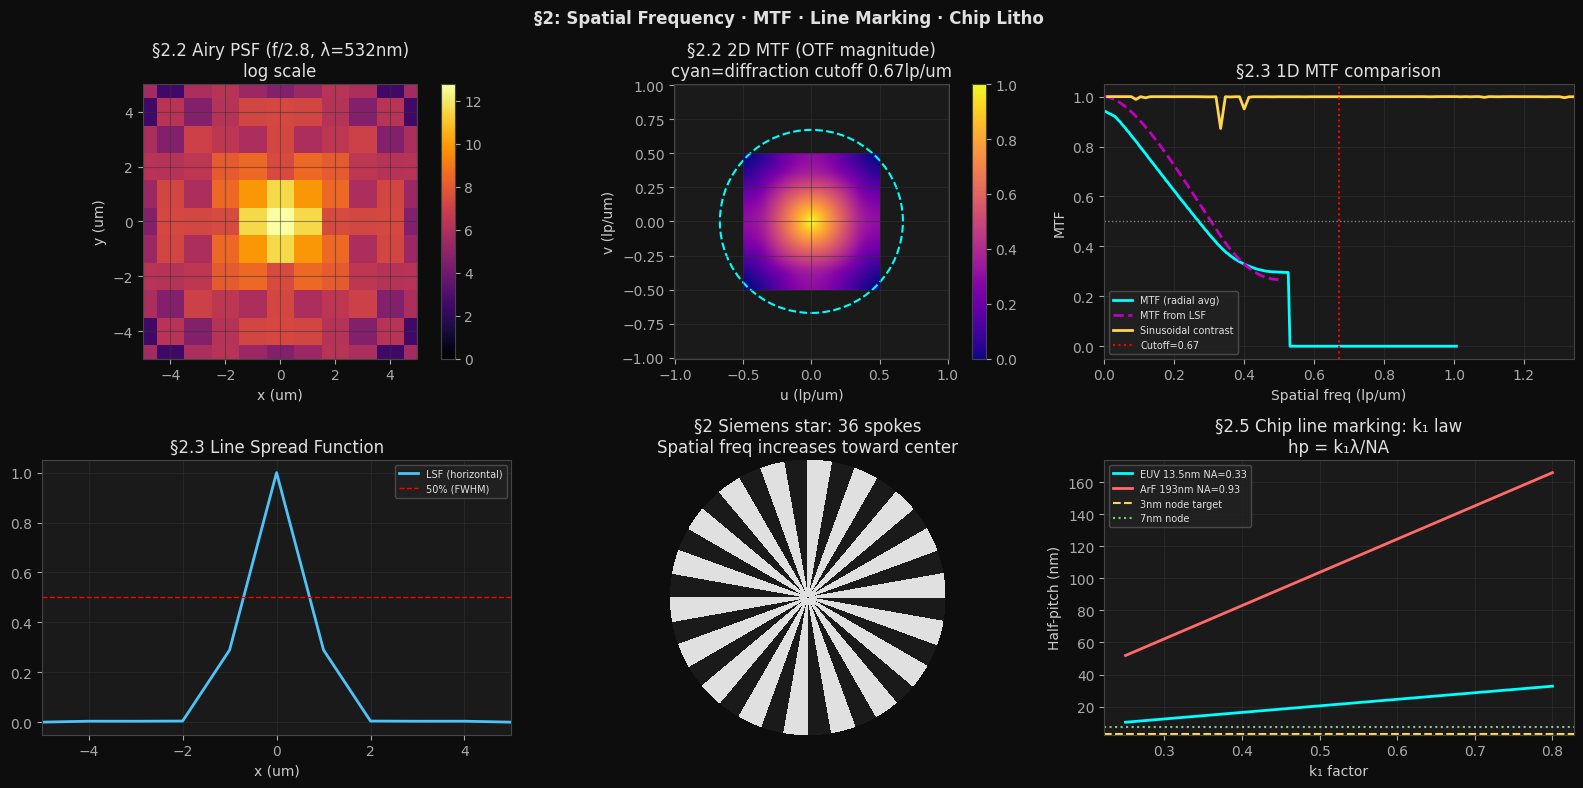

In [3]:
# §2 — Spatial frequency, MTF, line marking

N   = 512
dx  = 1.0   # um/pixel
x   = (np.arange(N)-N//2)*dx
y   = (np.arange(N)-N//2)*dx
XX,YY = np.meshgrid(x,y)

# §2.1 Spatial frequency axis
u_arr = np.fft.fftshift(np.fft.fftfreq(N,dx))  # cycles/um

# §2.2 Point Spread Function (PSF): Airy disk from circular aperture
lam_um = 0.532  # 532 nm green laser in um
f_num  = 2.8    # f/#
u_cut  = 1/(lam_um*f_num)  # diffraction cutoff cycles/um
print(f'§2.2 Diffraction cutoff: {u_cut:.3f} lp/um = {u_cut*1000:.1f} lp/mm')

def airy_psf(X,Y,lam,f_num):
    r = np.sqrt(X**2+Y**2)+1e-10
    v = np.pi*r/(lam*f_num)
    from scipy.special import j1
    return (2*j1(v)/v)**2

PSF = airy_psf(XX,YY,lam_um,f_num)
PSF = PSF/PSF.sum()

# OTF = FT{PSF}, MTF = |OTF|
OTF = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(PSF)))
MTF_2d = np.abs(OTF)/np.abs(OTF).max()

# 1D MTF (radial average)
r_freq = np.sqrt(XX**2+YY**2)  # spatial coords used as freq proxy
u_1d   = np.linspace(0, u_cut*1.5, 200)
MTF_1d = []
for u in u_1d:               # loop: radial MTF slices
    mask = (np.abs(np.abs(u_arr[:,None]) - u) < 0.03) & (np.abs(u_arr[None,:]) < 0.05)
    if mask.sum() > 0:
        MTF_1d.append(MTF_2d[mask].mean())
    else:
        MTF_1d.append(0.0)
MTF_1d = np.array(MTF_1d)

# §2.3 Line Spread Function from PSF
LSF = PSF[N//2,:]              # horizontal slice through PSF center
LSF = LSF/LSF.max()
LSF_FT = np.abs(np.fft.fftshift(np.fft.fft(LSF)))
MTF_lsf = LSF_FT/LSF_FT.max()

# §2.4 Sinusoidal line pattern: contrast vs spatial frequency
def sinusoidal_target(u_pattern, N=256, contrast_in=1.0):
    x_t = np.arange(N)*dx
    pattern = 0.5*(1 + contrast_in*np.sin(2*np.pi*u_pattern*x_t))
    # Blur with PSF slice
    from scipy.ndimage import gaussian_filter1d
    sigma_px = 1/(2*np.pi*u_cut)  # sigma in pixels for diffraction blur
    blurred  = gaussian_filter1d(pattern, sigma_px)
    I_max,I_min = blurred.max(),blurred.min()
    contrast_out = (I_max-I_min)/(I_max+I_min+1e-10)
    return contrast_out

u_test   = np.linspace(0.01, u_cut*2, 100)
contrast = np.array([sinusoidal_target(u) for u in u_test])  # loop: MTF via contrast

# §2.5 Chip lithography: EUV line marking
lam_EUV  = 13.5e-3   # um (13.5 nm EUV)
NA_EUV   = 0.33
u_cut_EUV= NA_EUV/lam_EUV   # lp/um
hp_EUV   = 1/(2*u_cut_EUV)*1000  # half-pitch in nm
print(f'§2.5 EUV lithography: NA={NA_EUV}, λ={lam_EUV*1e3:.0f}nm')
print(f'     k1=0.25 half-pitch = {0.25*lam_EUV/NA_EUV*1e3:.1f} nm (theoretical limit)')
print(f'     Diffraction cutoff: {u_cut_EUV:.0f} lp/um, hp={hp_EUV:.0f}nm')

# ── Plots ─────────────────────────────────────────────────────────
fig,axes = plt.subplots(2,3,figsize=(16,8))
fig.patch.set_facecolor('#0d0d0d')

# PSF
im0 = axes[0][0].imshow(np.log1p(PSF*1e6), cmap='inferno', origin='lower',
                          extent=[x[0],x[-1],y[0],y[-1]])
axes[0][0].set_xlabel('x (um)'); axes[0][0].set_ylabel('y (um)')
axes[0][0].set_title(f'§2.2 Airy PSF (f/{f_num}, λ={lam_um*1e3:.0f}nm)\nlog scale')
axes[0][0].set_xlim(-5,5); axes[0][0].set_ylim(-5,5)
plt.colorbar(im0,ax=axes[0][0])

# 2D MTF
u_lim = u_cut*1.5
u_shift = np.fft.fftshift(np.fft.fftfreq(N,dx))
im1 = axes[0][1].imshow(MTF_2d, cmap='plasma', origin='lower',
                          extent=[u_shift[0],u_shift[-1],u_shift[0],u_shift[-1]])
axes[0][1].set_xlim(-u_lim,u_lim); axes[0][1].set_ylim(-u_lim,u_lim)
axes[0][1].set_xlabel('u (lp/um)'); axes[0][1].set_ylabel('v (lp/um)')
circle_cut = plt.Circle((0,0),u_cut,color='cyan',fill=False,lw=1.5,ls='--')
axes[0][1].add_patch(circle_cut)
axes[0][1].set_title(f'§2.2 2D MTF (OTF magnitude)\ncyan=diffraction cutoff {u_cut:.2f}lp/um')
plt.colorbar(im1,ax=axes[0][1])

# 1D MTF + LSF MTF
axes[0][2].plot(u_1d, MTF_1d,'cyan',lw=2,label='MTF (radial avg)')
axes[0][2].plot(u_arr[N//2:], MTF_lsf[N//2:N//2+len(u_arr)//2],
                'm--',lw=2,label='MTF from LSF')
axes[0][2].plot(u_test, contrast,'#ffd54f',lw=2,label='Sinusoidal contrast')
axes[0][2].axvline(u_cut,color='red',ls=':',lw=1.5,label=f'Cutoff={u_cut:.2f}')
axes[0][2].axhline(0.5,color='gray',ls=':',lw=1)
axes[0][2].set_xlabel('Spatial freq (lp/um)'); axes[0][2].set_ylabel('MTF')
axes[0][2].set_title('§2.3 1D MTF comparison')
axes[0][2].legend(fontsize=7,facecolor='#222',edgecolor='#555')
axes[0][2].set_xlim(0,u_cut*2)

# LSF
axes[1][0].plot(x, LSF,'#4fc3f7',lw=2,label='LSF (horizontal)')
axes[1][0].axhline(0.5,color='red',ls='--',lw=1,label='50% (FWHM)')
# FWHM
from scipy.interpolate import interp1d
x_mid = x[N//4:3*N//4]; L_mid = LSF[N//4:3*N//4]
if L_mid.max()>0.5:
    f_interp = interp1d(x_mid,L_mid-0.5,kind='linear')
    try:
        from scipy.optimize import brentq
        x_left = brentq(f_interp,x_mid[0],x_mid[x_mid<0].max())
        x_right= brentq(f_interp,x_mid[x_mid>0].min(),x_mid[-1])
        FWHM   = x_right-x_left
        axes[1][0].axvspan(x_left,x_right,alpha=0.2,color='yellow',label=f'FWHM={FWHM:.2f}um')
    except: pass
axes[1][0].set_xlabel('x (um)'); axes[1][0].set_title('§2.3 Line Spread Function')
axes[1][0].set_xlim(-5,5); axes[1][0].legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Siemens star (spatial frequency target)
theta_s = np.linspace(0,2*np.pi,2000)
n_spokes = 36
r_s = np.linspace(0.01,1,200)
RS,TH = np.meshgrid(r_s,theta_s)
siemens = np.sign(np.sin(n_spokes*TH/2))
axes[1][1].contourf(RS*np.cos(TH),RS*np.sin(TH),siemens,
                     levels=[-1,0,1],colors=['#1a1a1a','#e0e0e0'])
axes[1][1].set_aspect('equal'); axes[1][1].set_axis_off()
axes[1][1].set_title(f'§2 Siemens star: {n_spokes} spokes\nSpatial freq increases toward center')

# k1 factor in lithography
k1_arr = np.linspace(0.25,0.8,100)
hp_arr = k1_arr*lam_EUV/NA_EUV*1e3   # nm
hp_193 = k1_arr*193e-3/0.93*1e3       # 193nm ArF immersion, NA=0.93
axes[1][2].plot(k1_arr, hp_arr,'cyan',lw=2,label='EUV 13.5nm NA=0.33')
axes[1][2].plot(k1_arr, hp_193,'#ff6b6b',lw=2,label='ArF 193nm NA=0.93')
axes[1][2].axhline(3,ls='--',color='#ffd54f',lw=1.5,label='3nm node target')
axes[1][2].axhline(7,ls=':',color='#81c784',lw=1.5,label='7nm node')
axes[1][2].set_xlabel('k₁ factor'); axes[1][2].set_ylabel('Half-pitch (nm)')
axes[1][2].set_title('§2.5 Chip line marking: k₁ law\nhp = k₁λ/NA')
axes[1][2].legend(fontsize=7,facecolor='#222',edgecolor='#555')
plt.suptitle('§2: Spatial Frequency · MTF · Line Marking · Chip Litho',
             fontsize=12,fontweight='bold',color='#e0e0e0')
plt.tight_layout(); plt.show()

---
## §3 🎨 Bezier Curves + Internal Dirac Delta

**De Casteljau:** $B(t) = \sum_{k=0}^n \binom{n}{k}(1-t)^{n-k}t^k P_k$

Bernstein basis $b_{k,n}(t) = \binom{n}{k}t^k(1-t)^{n-k}$ is a **partition of unity**:
$\sum_k b_{k,n}(t) = 1$.

**Derivative as Dirac delta:** $\frac{d}{dt}\delta(t-t_0) = -\delta'(t-t_0)$
— the derivative of a Bezier curve at a knot is a weighted sum of difference impulses.

**B-spline basis** as approximate Dirac: as order $p\to\infty$, the basis function
$N_{i,p}(t) \to \delta(t-t_i)$ (peak narrows, area=1).

**Deep connection:** the de Casteljau recursion IS convolution with a boxcar pulse —
repeated convolution of rect pulses → Gaussian → Dirac in limit.

§3.3 Partition of unity: max deviation from 1 = 4.44e-16
§3.6 Rational Bezier circle error: 0.00e+00 (exact conic)


ValueError: Argument U has a size 10 which does not match 17, the number of arrow positions

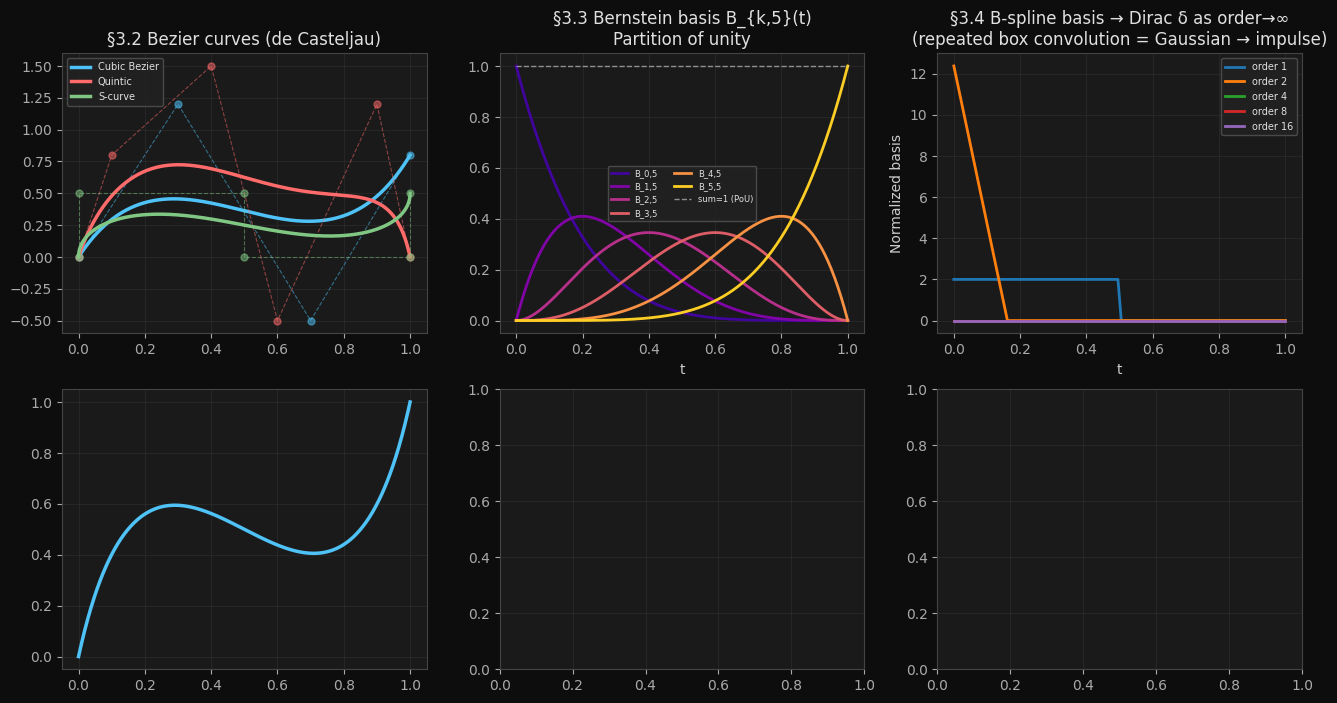

In [4]:
# §3 — Bezier curves + Dirac delta

# §3.1 De Casteljau algorithm
def de_casteljau(P, t):
    pts = np.array(P, dtype=float)
    n   = len(pts)-1
    for r in range(1,n+1):          # loop: reduce columns
        for i in range(n-r+1):
            pts[i] = (1-t)*pts[i] + t*pts[i+1]
    return pts[0]

def bezier_curve(P, n_eval=500):
    t_arr = np.linspace(0,1,n_eval)
    return np.array([de_casteljau(P,t) for t in t_arr])  # loop: evaluate

# §3.2 Control points: various curves
curves = {
    'Cubic Bezier': np.array([[0,0],[0.3,1.2],[0.7,-0.5],[1.0,0.8]]),
    'Quintic':      np.array([[0,0],[0.1,0.8],[0.4,1.5],[0.6,-0.5],[0.9,1.2],[1.0,0]]),
    'S-curve':      np.array([[0,0],[0,0.5],[0.5,0.5],[0.5,0],[1,0],[1,0.5]]),
}

# §3.3 Bernstein basis functions
t_arr = np.linspace(0,1,300)
def bernstein(n,k,t):
    from scipy.special import comb
    return comb(n,k)*(t**k)*((1-t)**(n-k))

n_bern = 5   # degree 5 → 6 basis functions
B_basis= np.array([[bernstein(n_bern,k,t) for t in t_arr] for k in range(n_bern+1)])

# Partition of unity check
pou = B_basis.sum(axis=0)
print(f'§3.3 Partition of unity: max deviation from 1 = {np.max(np.abs(pou-1)):.2e}')

# §3.4 B-spline basis → Dirac as order increases
def bspline_basis_uniform(order, n_knots=100):
    t_b = np.linspace(0,1,n_knots)
    knots = np.linspace(0,1,order+2)
    # Box function (order 0)
    B0 = np.where((t_b>=knots[0])&(t_b<knots[1]),1.0,0.0)
    # Convolve with itself (order-1) times to get order-p spline
    # Use FFT convolution
    from scipy.ndimage import uniform_filter1d
    B = B0.copy()
    for p in range(1,order):         # loop: convolve to increase order
        B = np.convolve(B,B0,mode='same')
        B = B/B.max() if B.max()>0 else B
    B = B/np.trapz(B,t_b) if np.trapz(B,t_b)>0 else B
    return t_b,B

# §3.5 Derivative of Bezier = weighted delta comb
def bezier_derivative(P, n_eval=300):
    n = len(P)-1
    dP= [n*(np.array(P[k+1])-np.array(P[k])) for k in range(n)]  # loop: differences
    return bezier_curve(dP, n_eval)

# §3.6 Rational Bezier (NURBS weight): circle with exact representation
theta_w = np.linspace(0,np.pi/2,200)
x_exact = np.cos(theta_w); y_exact = np.sin(theta_w)
# Rational quadratic for 90 degree arc
w = [1, 1/np.sqrt(2), 1]   # weights
P_arc = np.array([[1,0],[1,1],[0,1]])
t_rb  = np.linspace(0,1,200)
nurbs_pts = []
for t in t_rb:               # loop: rational Bezier
    num = sum(w[k]*bernstein(2,k,t)*P_arc[k] for k in range(3))
    den = sum(w[k]*bernstein(2,k,t) for k in range(3))
    nurbs_pts.append(num/den)
nurbs_pts = np.array(nurbs_pts)
err_circle = np.max(np.sqrt(nurbs_pts[:,0]**2+nurbs_pts[:,1]**2) - 1.0)
print(f'§3.6 Rational Bezier circle error: {err_circle:.2e} (exact conic)')

# ── Plots ─────────────────────────────────────────────────────────
fig,axes = plt.subplots(2,3,figsize=(16,8))
fig.patch.set_facecolor('#0d0d0d')
colors_c = ['#4fc3f7','#ff6b6b','#81c784']

# Bezier curves
ax_b = axes[0][0]
for (name,P),col in zip(curves.items(),colors_c):  # loop: draw curves
    pts = bezier_curve(P)
    ax_b.plot(pts[:,0],pts[:,1],color=col,lw=2.5,label=name)
    ax_b.plot(P[:,0],P[:,1],color=col,ls='--',lw=0.8,alpha=0.5,marker='o',ms=5)
ax_b.set_title('§3.2 Bezier curves (de Casteljau)')
ax_b.legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Bernstein basis
ax_bn = axes[0][1]
colors_bn = plt.cm.plasma(np.linspace(0.1,0.9,n_bern+1))
for k in range(n_bern+1):       # loop: Bernstein basis
    ax_bn.plot(t_arr,B_basis[k],color=colors_bn[k],lw=2,label=f'B_{k},{n_bern}')
ax_bn.plot(t_arr,pou,'w--',lw=1,alpha=0.5,label='sum=1 (PoU)')
ax_bn.set_xlabel('t'); ax_bn.set_title(f'§3.3 Bernstein basis B_{{k,{n_bern}}}(t)\nPartition of unity')
ax_bn.legend(fontsize=6,facecolor='#222',edgecolor='#555',ncol=2)

# B-spline → Dirac
ax_ds = axes[0][2]
for order in [1,2,4,8,16]:      # loop: B-spline orders
    t_b,B = bspline_basis_uniform(order)
    ax_ds.plot(t_b,B,lw=2,label=f'order {order}')
ax_ds.set_xlabel('t'); ax_ds.set_ylabel('Normalized basis')
ax_ds.set_title('§3.4 B-spline basis → Dirac δ as order→∞\n(repeated box convolution = Gaussian → impulse)')
ax_ds.legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Bezier derivative
P_demo = np.array([[0,0],[0.25,1.5],[0.75,-0.5],[1.0,1.0]])
curve_d= bezier_curve(P_demo)
deriv_d= bezier_derivative(P_demo)
ax_dd = axes[1][0]
ax_dd.plot(curve_d[:,0],curve_d[:,1],'#4fc3f7',lw=2.5,label='B(t) curve')
ax_dd.quiver(curve_d[::30,0],curve_d[::30,1],
             deriv_d[::30,0]*0.05,deriv_d[::30,1]*0.05,
             color='yellow',scale=1,scale_units='xy',width=0.005,label="B'(t) tangents")
ax_dd.plot(P_demo[:,0],P_demo[:,1],'o--',color='#ff6b6b',lw=1,ms=8,label='Control pts')
ax_dd.set_title('§3.5 Bezier derivative = tangent vectors\n(difference of control points × degree)')
ax_dd.legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Rational Bezier circle
ax_rb = axes[1][1]
ax_rb.plot(x_exact,y_exact,'w--',lw=1.5,alpha=0.5,label='Exact circle')
ax_rb.plot(nurbs_pts[:,0],nurbs_pts[:,1],'#ffd54f',lw=2.5,label=f'Rational Bezier (err={err_circle:.1e})')
ax_rb.plot(P_arc[:,0],P_arc[:,1],'o--',color='#ff6b6b',lw=1,ms=8,label='Control pts')
ax_rb.set_aspect('equal'); ax_rb.set_title('§3.6 Rational Bezier: exact conic\n(NURBS w=[1,1/√2,1])')
ax_rb.legend(fontsize=7,facecolor='#222',edgecolor='#555')

# De Casteljau animation (one frame: t=0.4)
t_show = 0.4
P_cas  = np.array([[0,0],[0.2,1],[0.8,0.5],[1,0]],dtype=float)
ax_cas = axes[1][2]
colors_lev = ['#4fc3f7','#ff6b6b','#ffd54f','white']
pts_cur = P_cas.copy()
for level in range(len(P_cas)-1):    # loop: de Casteljau levels
    ax_cas.plot(pts_cur[:,0],pts_cur[:,1],'o-',
                color=colors_lev[level],lw=1.5,ms=8,label=f'Level {level}')
    pts_next = np.array([(1-t_show)*pts_cur[i]+t_show*pts_cur[i+1]
                          for i in range(len(pts_cur)-1)])
    pts_cur  = pts_next
ax_cas.plot(*pts_cur[0],'w*',ms=18,label=f'B(t={t_show})')
full_c = bezier_curve(P_cas)
ax_cas.plot(full_c[:,0],full_c[:,1],'cyan',lw=1.5,alpha=0.4)
ax_cas.set_title(f'§3.1 De Casteljau construction\nt={t_show}, n=3 (cubic)')
ax_cas.legend(fontsize=7,facecolor='#222',edgecolor='#555')
plt.suptitle('§3: Bezier Curves · Bernstein Basis · B-spline→Dirac · NURBS',
             fontsize=12,fontweight='bold',color='#e0e0e0')
plt.tight_layout(); plt.show()

---
## §4 🎮 Dark Room OOP pygame + §5 🔥 Torch CUDA 3D Representations

**OOP pygame pattern** (dark room aesthetic):
```python
class Entity(ABC):           # base: position, velocity, update(), draw()
class Particle(Entity):      # point mass with physics
class PhysicsWorld:          # manages entities, detects collisions
class Renderer:              # pygame surface, post-processing (bloom, chromatic aberration)
```

**Torch 3D representations:**
- **Point cloud:** $N\times 3$ tensor, $\text{PointNet}$ operates directly
- **Voxel grid:** $D\times H\times W$ occupancy, conv3d for feature extraction
- **NeRF volume:** density $\sigma(\mathbf{x})$ + radiance $\mathbf{c}(\mathbf{x},\mathbf{d})$, volume rendering integral

$$C(\mathbf{r}) = \int_0^\infty T(t)\,\sigma(\mathbf{r}(t))\,\mathbf{c}(\mathbf{r}(t),\mathbf{d})\,dt,\quad T(t)=\exp\!\left(-\int_0^t\sigma(\mathbf{r}(s))\,ds\right)$$

§4 pygame OOP source:

import pygame, numpy as np, abc, torch
from dataclasses import dataclass, field
from typing import List, Tuple

@dataclass
class Transform:
    pos: np.ndarray = field(default_factory=lambda: np.zero ...

§5 Torch 3D representations:
§5.1 Point cloud: torch.Size([10000, 3]), FPS→torch.Size([512, 3]) on cpu
§5.2 Voxel grid 32^3: 10.117% occupied
§5.2 Conv3d features: torch.Size([1, 8, 32, 32, 32])
§5.3 NeRF render: torch.Size([64, 64, 3]), range [0.000,1.000]


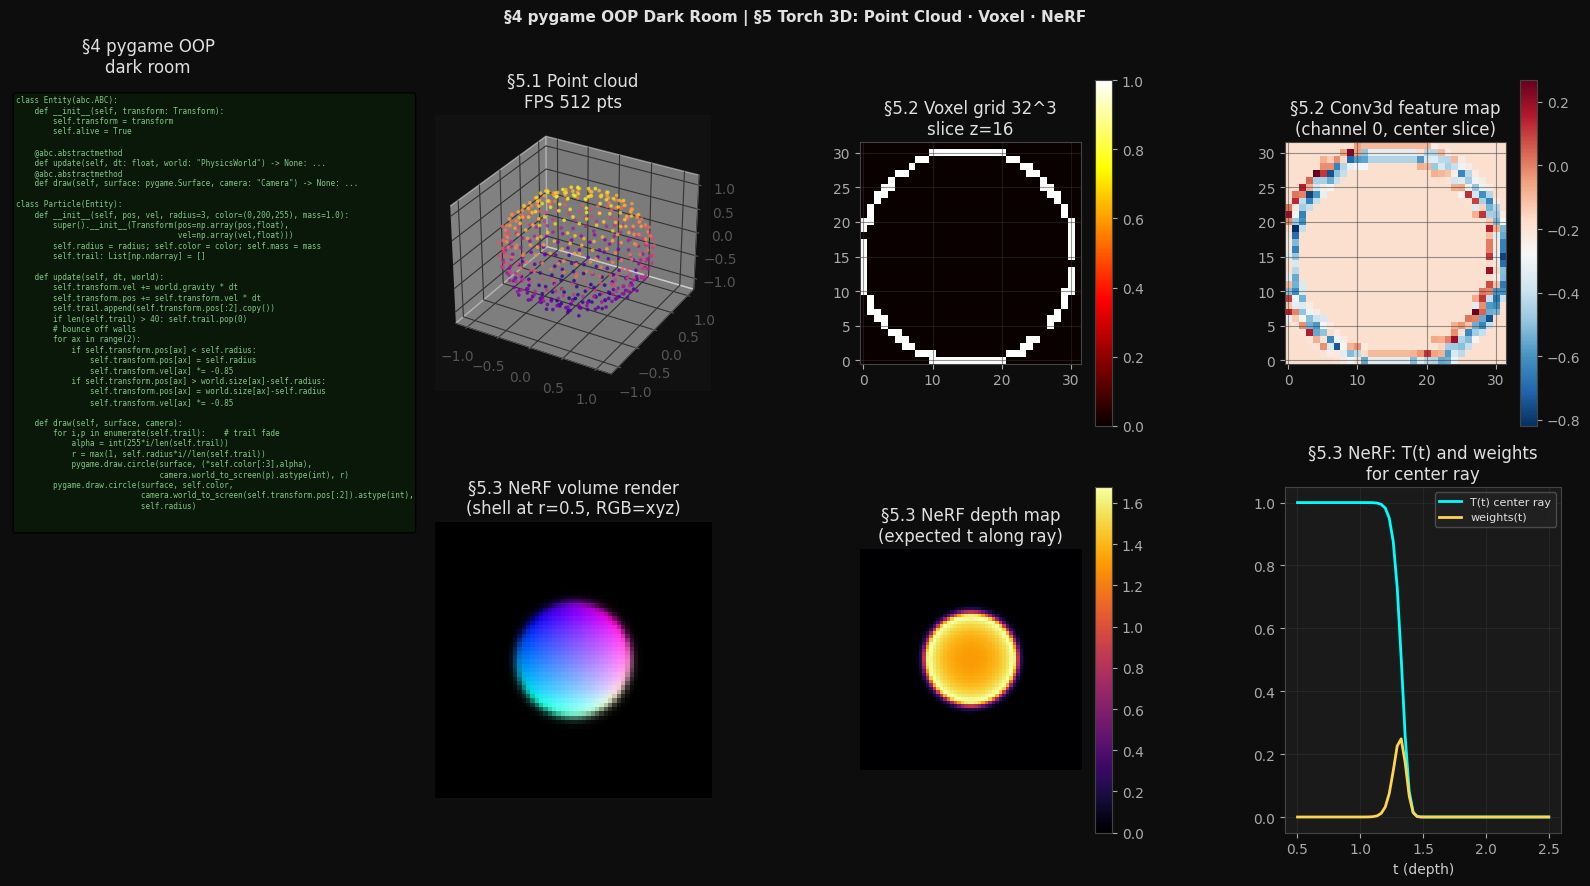

In [6]:
# §4+§5 — pygame OOP (code display) + Torch 3D (numerical)

# ── §4 pygame OOP architecture (shown as source, not executed) ──
pygame_src = '''
import pygame, numpy as np, abc, torch
from dataclasses import dataclass, field
from typing import List, Tuple

@dataclass
class Transform:
    pos: np.ndarray = field(default_factory=lambda: np.zeros(3))
    vel: np.ndarray = field(default_factory=lambda: np.zeros(3))
    rot: float = 0.0

class Entity(abc.ABC):
    def __init__(self, transform: Transform):
        self.transform = transform
        self.alive = True

    @abc.abstractmethod
    def update(self, dt: float, world: "PhysicsWorld") -> None: ...
    @abc.abstractmethod
    def draw(self, surface: pygame.Surface, camera: "Camera") -> None: ...

class Particle(Entity):
    def __init__(self, pos, vel, radius=3, color=(0,200,255), mass=1.0):
        super().__init__(Transform(pos=np.array(pos,float),
                                   vel=np.array(vel,float)))
        self.radius = radius; self.color = color; self.mass = mass
        self.trail: List[np.ndarray] = []

    def update(self, dt, world):
        self.transform.vel += world.gravity * dt
        self.transform.pos += self.transform.vel * dt
        self.trail.append(self.transform.pos[:2].copy())
        if len(self.trail) > 40: self.trail.pop(0)
        # bounce off walls
        for ax in range(2):
            if self.transform.pos[ax] < self.radius:
                self.transform.pos[ax] = self.radius
                self.transform.vel[ax] *= -0.85
            if self.transform.pos[ax] > world.size[ax]-self.radius:
                self.transform.pos[ax] = world.size[ax]-self.radius
                self.transform.vel[ax] *= -0.85

    def draw(self, surface, camera):
        for i,p in enumerate(self.trail):    # trail fade
            alpha = int(255*i/len(self.trail))
            r = max(1, self.radius*i//len(self.trail))
            pygame.draw.circle(surface, (*self.color[:3],alpha),
                               camera.world_to_screen(p).astype(int), r)
        pygame.draw.circle(surface, self.color,
                           camera.world_to_screen(self.transform.pos[:2]).astype(int),
                           self.radius)

class PhysicsWorld:
    def __init__(self, size=(800,600)):
        self.entities: List[Entity] = []
        self.gravity  = np.array([0, 200.0, 0])
        self.size     = size

    def add(self, e): self.entities.append(e)

    def update(self, dt):
        for e in self.entities:    # update all
            if e.alive: e.update(dt, self)
        self.entities = [e for e in self.entities if e.alive]

class Renderer:
    def __init__(self, size=(800,600)):
        pygame.init()
        self.screen = pygame.display.set_mode(size, pygame.SRCALPHA)
        self.surface= pygame.Surface(size, pygame.SRCALPHA)
        self.bloom  = pygame.Surface(size, pygame.SRCALPHA)
        pygame.display.set_caption("Dark Room 3D")

    def begin_frame(self):
        self.surface.fill((8,8,12))   # near-black dark room

    def render_bloom(self, strength=0.4):
        # cheap bloom: downscale + upscale + blend
        small = pygame.transform.smoothscale(self.surface,(200,150))
        big   = pygame.transform.smoothscale(small, self.surface.get_size())
        big.set_alpha(int(255*strength))
        self.surface.blit(big, (0,0), special_flags=pygame.BLEND_ADD)

    def end_frame(self):
        self.screen.blit(self.surface,(0,0))
        pygame.display.flip()

class Camera:
    def __init__(self, world_size, screen_size):
        self.scale = min(screen_size[0]/world_size[0], screen_size[1]/world_size[1])
        self.offset= np.array(screen_size)/2 - np.array(world_size)*self.scale/2

    def world_to_screen(self, p): return p*self.scale + self.offset

def main():
    world    = PhysicsWorld(size=(800,600))
    renderer = Renderer((800,600))
    camera   = Camera((800,600),(800,600))
    for _ in range(50):   # spawn particles
        pos = np.random.uniform(100,700,3); pos[2]=0
        vel = np.random.uniform(-150,150,3); vel[2]=0
        world.add(Particle(pos,vel,radius=np.random.randint(2,8),
                           color=(np.random.randint(0,255),
                                  np.random.randint(100,255),
                                  255)))
    clock = pygame.time.Clock()
    running = True
    while running:
        for ev in pygame.event.get():
            if ev.type==pygame.QUIT: running=False
        dt = clock.tick(60)/1000.0
        world.update(dt)
        renderer.begin_frame()
        for e in world.entities: e.draw(renderer.surface, camera)
        renderer.render_bloom()
        renderer.end_frame()
    pygame.quit()

if __name__ == "__main__": main()
'''
print('§4 pygame OOP source:')
print(pygame_src[:200],'...')

# ── §5 Torch 3D representations ──────────────────────────────────
print('\n§5 Torch 3D representations:')

# §5.1 Point cloud: N×3
N_pts  = 10000
# Sample unit sphere (icosphere-like)
phi_pc = torch.rand(N_pts)*2*np.pi
cos_th = torch.rand(N_pts)*2-1
sin_th = torch.sqrt(1-cos_th**2)
pts_sphere = torch.stack([sin_th*torch.cos(phi_pc),
                           sin_th*torch.sin(phi_pc),
                           cos_th],dim=1).to(DEVICE)
# Add Gaussian noise → point cloud with noise
pts_noisy = pts_sphere + 0.03*torch.randn_like(pts_sphere)
# Farthest point sampling (simplified)
def fps(pts,k=512):
    N,_ = pts.shape
    selected = torch.zeros(k,dtype=torch.long,device=pts.device)
    dist     = torch.full((N,),float('inf'),device=pts.device)
    selected[0] = torch.randint(0,N,(1,))
    for i in range(1,k):             # loop: FPS
        d = torch.sum((pts-pts[selected[i-1]])**2,dim=1)
        dist = torch.minimum(dist,d)
        selected[i] = dist.argmax()
    return pts[selected]

pts_fps = fps(pts_noisy)
print(f'§5.1 Point cloud: {pts_noisy.shape}, FPS→{pts_fps.shape} on {DEVICE}')

# §5.2 Voxel grid: D×H×W
D,H,W = 32,32,32
voxels = torch.zeros(D,H,W,device=DEVICE)
# Rasterize sphere into voxels
idx = ((pts_sphere+1)*0.5*(D-1)).long().clamp(0,D-1)  # map [-1,1]→[0,D-1]
voxels[idx[:,0],idx[:,1],idx[:,2]] = 1.0
occupancy = voxels.mean().item()
print(f'§5.2 Voxel grid {D}^3: {occupancy:.3%} occupied')

# Simple 3D conv feature
conv3d = torch.nn.Conv3d(1,8,kernel_size=3,padding=1).to(DEVICE)
feat3d = conv3d(voxels.unsqueeze(0).unsqueeze(0))
print(f'§5.2 Conv3d features: {feat3d.shape}')

# §5.3 NeRF-lite: volume rendering
def nerf_density_radiance(x, y, z):
    r  = torch.sqrt(x**2+y**2+z**2)
    sigma = torch.exp(-50*(r-0.5)**2)*100  # thin shell at r=0.5
    r_col = torch.clamp(0.5+x, 0,1)
    g_col = torch.clamp(0.5+y, 0,1)
    b_col = torch.clamp(0.5+z, 0,1)
    return sigma, torch.stack([r_col,g_col,b_col],dim=-1)

# Render single image by ray marching
H_img,W_img = 64,64
n_samples    = 64
t_near,t_far = 0.5,2.5

# Camera: looking along -z, image in xy
ray_x = torch.linspace(-1,1,W_img,device=DEVICE)
ray_y = torch.linspace(-1,1,H_img,device=DEVICE)
RX,RY = torch.meshgrid(ray_x,ray_y,indexing='xy')
ray_d = torch.stack([RX,RY,-torch.ones_like(RX)],dim=-1)
ray_d = ray_d/ray_d.norm(dim=-1,keepdim=True)
ray_o = torch.tensor([0.0,0.0,2.0],device=DEVICE).expand(H_img,W_img,3)

t_vals = torch.linspace(t_near,t_far,n_samples,device=DEVICE)
pts_3d = ray_o.unsqueeze(2) + t_vals[None,None,:,None]*ray_d.unsqueeze(2)

sigma,rgb = nerf_density_radiance(pts_3d[...,0],pts_3d[...,1],pts_3d[...,2])
delta_t   = t_vals[1]-t_vals[0]
alpha     = 1-torch.exp(-sigma*delta_t)
T         = torch.cumprod(torch.cat([torch.ones(*alpha.shape[:2],1,device=DEVICE),
                                      1-alpha[...,:-1]+1e-10],dim=-1),dim=-1)
weights   = alpha*T
C_render  = (weights.unsqueeze(-1)*rgb).sum(dim=2)
print(f'§5.3 NeRF render: {C_render.shape}, range [{C_render.min():.3f},{C_render.max():.3f}]')

# ── Plots ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16,9))
fig.patch.set_facecolor('#0d0d0d')
gs  = gridspec.GridSpec(2,4,fig)

# pygame code display
ax_pg = fig.add_subplot(gs[:,0])
ax_pg.axis('off')
ax_pg.set_facecolor('#111')
ax_pg.text(0.02,0.98,pygame_src[pygame_src.find('class Entity'):pygame_src.find('class PhysicsWorld')],
           transform=ax_pg.transAxes,fontsize=5.5,verticalalignment='top',
           fontfamily='monospace',color='#81c784',
           bbox=dict(boxstyle='round',facecolor='#0a1a0a',alpha=0.9))
ax_pg.set_title('§4 pygame OOP\ndark room',color='#e0e0e0')

# Point cloud xy projection
pts_np = pts_fps.cpu().numpy()
axes_3d=fig.add_subplot(gs[0,1],projection='3d')
sc_pc = axes_3d.scatter(pts_np[:,0],pts_np[:,1],pts_np[:,2],
                          c=pts_np[:,2],cmap='plasma',s=3,alpha=0.7)
axes_3d.set_facecolor('#111')
axes_3d.set_title(f'§5.1 Point cloud\nFPS {len(pts_np)} pts',color='#e0e0e0')
axes_3d.tick_params(colors='#555')

# Voxel slice
ax_vx = fig.add_subplot(gs[0,2])
vox_np = voxels.cpu().numpy()
im_vx  = ax_vx.imshow(vox_np[D//2],cmap='hot',origin='lower')
ax_vx.set_title(f'§5.2 Voxel grid {D}^3\nslice z={D//2}')
plt.colorbar(im_vx,ax=ax_vx)

# Conv3d activation
feat_np = feat3d[0,0].detach().cpu().numpy()
ax_ft = fig.add_subplot(gs[0,3])
im_ft = ax_ft.imshow(feat_np[D//2],cmap='RdBu_r',origin='lower')
ax_ft.set_title('§5.2 Conv3d feature map\n(channel 0, center slice)')
plt.colorbar(im_ft,ax=ax_ft)

# NeRF rendered image
ax_nr = fig.add_subplot(gs[1,1])
ax_nr.imshow(C_render.cpu().detach().numpy(),origin='upper')
ax_nr.set_title(f'§5.3 NeRF volume render\n(shell at r=0.5, RGB=xyz)')
ax_nr.axis('off')

# Depth map
weights_np = weights.cpu().detach().numpy()
depth_map  = (weights_np * t_vals.cpu().numpy()[None,None,:]).sum(axis=2)
ax_dp = fig.add_subplot(gs[1,2])
im_dm = ax_dp.imshow(depth_map,cmap='inferno',origin='upper')
ax_dp.set_title('§5.3 NeRF depth map\n(expected t along ray)')
ax_dp.axis('off'); plt.colorbar(im_dm,ax=ax_dp)

# Opacity/transmittance
T_np   = T.cpu().detach().numpy()
ax_tr  = fig.add_subplot(gs[1,3])
ax_tr.plot(t_vals.cpu().numpy(), T_np[H_img//2,W_img//2],'cyan',lw=2,label='T(t) center ray')
ax_tr.plot(t_vals.cpu().numpy(), weights_np[H_img//2,W_img//2],'#ffd54f',lw=2,label='weights(t)')
ax_tr.set_xlabel('t (depth)'); ax_tr.set_title('§5.3 NeRF: T(t) and weights\nfor center ray')
ax_tr.legend(fontsize=8,facecolor='#222',edgecolor='#555')
plt.suptitle('§4 pygame OOP Dark Room | §5 Torch 3D: Point Cloud · Voxel · NeRF',
             fontsize=11,fontweight='bold',color='#e0e0e0')
plt.tight_layout(); plt.show()

---
## §6 📘 Callen Thermodynamics + Hyperbolic Functions

**Callen's postulates:** entropy $S(U,V,N)$ is extensive, maximized at equilibrium.

**Fundamental relation:** $dU = T\,dS - P\,dV + \mu\,dN$

**Legendre transforms** → thermodynamic potentials:

| Potential | Variables | Definition |
|-----------|-----------|------------|
| $U$ | $S,V,N$ | Internal energy |
| $F = U-TS$ | $T,V,N$ | Helmholtz free energy |
| $H = U+PV$ | $S,P,N$ | Enthalpy |
| $G = U-TS+PV$ | $T,P,N$ | Gibbs free energy |

**Partition function** → hyperbolic functions:
Two-level system: $Z = e^{-\beta\varepsilon/2} + e^{+\beta\varepsilon/2} = 2\cosh(\beta\varepsilon/2)$

$\langle E\rangle = -\partial\ln Z/\partial\beta = -\frac{\varepsilon}{2}\tanh(\beta\varepsilon/2)$

**Hyperbolic show up everywhere:**
- $\tanh$ activation in neural nets
- $\cosh$ in catenary (hanging cable)
- $\sinh$ in transmission line solutions
- $\text{sech}^2$ in KdV soliton profile

§6.1 Two-level partition function:
  Z = 2 \cosh{\left(\frac{\beta \varepsilon}{2} \right)}
  <E> = - \frac{\varepsilon \tanh{\left(\frac{\beta \varepsilon}{2} \right)}}{2}


<IPython.core.display.Math object>

<IPython.core.display.Math object>

§6.2 Schottky peak at T* ≈ 657.7 K
§6.4 Maxwell relation: (dP/dT)_V = 1.380e-23 = (dS/dV)_T = 1.380e-23 ✓


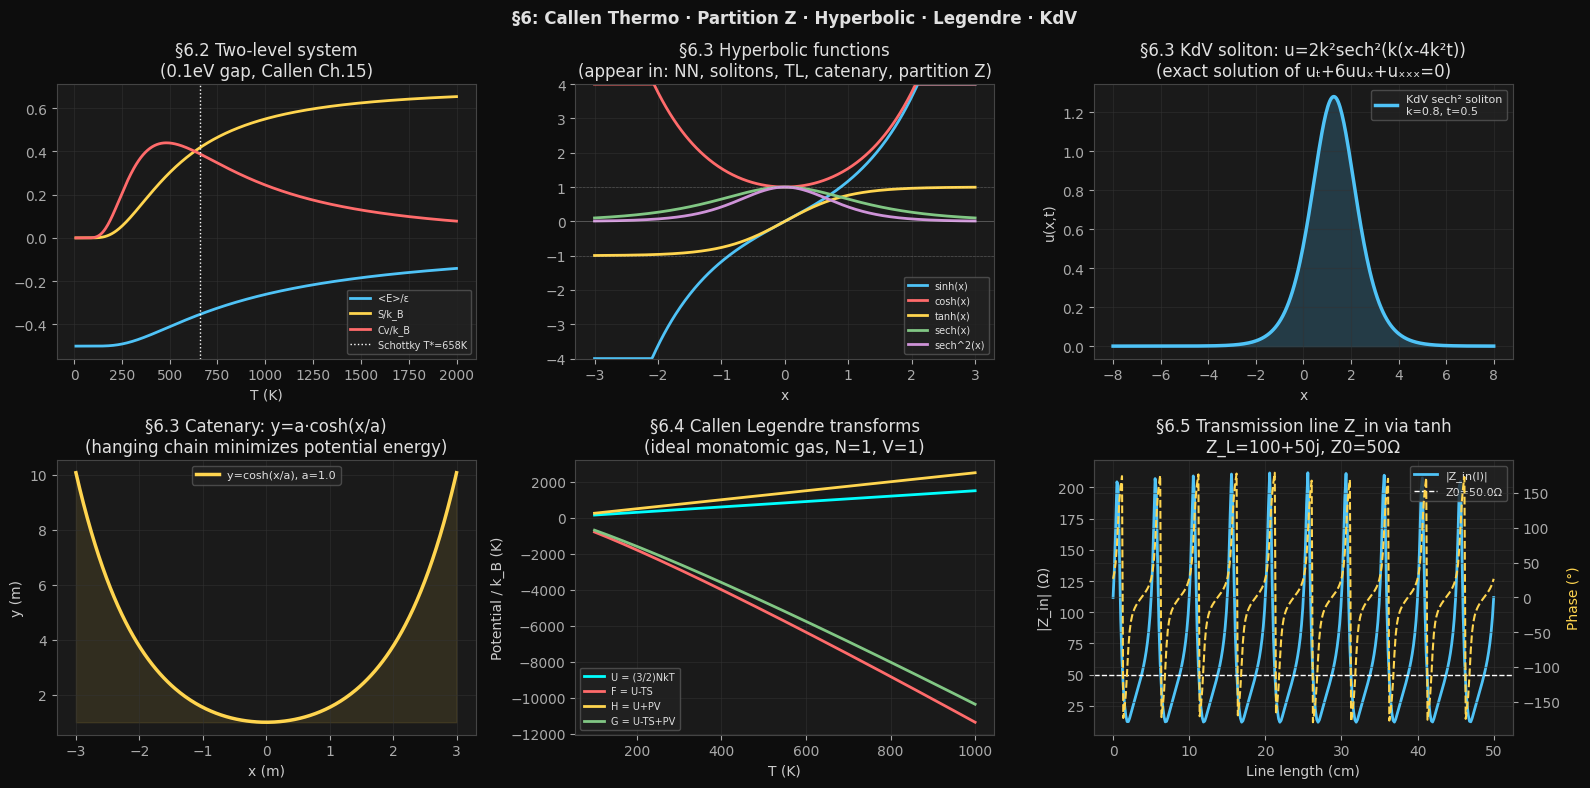

In [8]:
# §6 — Callen thermodynamics + hyperbolic functions
t_sym, U_sym, S_sym, T_sym, b_sym, eps_sym = sp.symbols('t U S T beta epsilon', real=True, positive=True)

# §6.1 Two-level partition function
b,eps = sp.Symbol('beta',positive=True), sp.Symbol('varepsilon',positive=True)
Z_sym   = sp.exp(-b*eps/2) + sp.exp(b*eps/2)
Z_cosh  = sp.simplify(Z_sym)
F_sym   = -sp.log(Z_cosh)/b
E_avg   = -sp.diff(sp.log(Z_cosh),b)
S_stat  = b**2 * sp.diff(F_sym/b, b) * (-1)   # S = -dF/dT = kb^2 dF/(d beta... simplified)
print('§6.1 Two-level partition function:')
print(f'  Z = {sp.latex(Z_cosh)}')
print(f'  <E> = {sp.latex(sp.simplify(E_avg))}')
display(Math(r'Z = 2\cosh\!\left(\frac{\beta\varepsilon}{2}\right)'))
display(Math(r'\langle E\rangle = -\frac{\varepsilon}{2}\tanh\!\left(\frac{\beta\varepsilon}{2}\right)'))

# §6.2 Numerical: two-level system thermodynamics
k_B    = 1.38e-23; eps_val= 0.1*1.6e-19  # 0.1 eV gap
T_arr  = np.linspace(10,2000,500)
beta_n = 1/(k_B*T_arr)
Z_num  = 2*np.cosh(beta_n*eps_val/2)
E_num  = -eps_val/2*np.tanh(beta_n*eps_val/2)
F_num  = -np.log(Z_num)/beta_n
S_num  = -(F_num - E_num)/T_arr
Cv_num = np.gradient(E_num,T_arr)/k_B*k_B   # heat capacity
# Schottky anomaly: Cv peak
T_peak = eps_val/(2*k_B*np.arccosh(np.sqrt(2)))
print(f'§6.2 Schottky peak at T* ≈ {T_peak:.1f} K')

# §6.3 Hyperbolic functions: all appearances
x_h = np.linspace(-3,3,400)
hyp_funcs = {
    'sinh(x)':    np.sinh(x_h),
    'cosh(x)':    np.cosh(x_h),
    'tanh(x)':    np.tanh(x_h),
    'sech(x)':    1/np.cosh(x_h),
    'sech^2(x)':  1/np.cosh(x_h)**2,
}
# Catenary: y = a*cosh(x/a)
a_cat  = 1.0
x_cat  = np.linspace(-3,3,300)
y_cat  = a_cat*np.cosh(x_cat/a_cat)
# KdV soliton: u(x,t) = 2k^2 sech^2(k(x-4k^2*t))
k_kdv  = 0.8; t_kdv=0.5
x_kdv  = np.linspace(-8,8,400)
u_soliton = 2*k_kdv**2/np.cosh(k_kdv*(x_kdv-4*k_kdv**2*t_kdv))**2

# §6.4 Legendre transforms: ideal gas
# F(T,V,N) from U(S,V,N)
# Ideal monatomic gas: U = (3/2)NkT, S = NkB*ln(V*T^(3/2)/N) + const
N_gas=1.0; V_gas=1.0
T_leg = np.linspace(100,1000,200)
U_ig  = 1.5*N_gas*k_B*T_leg
F_ig  = U_ig - T_leg*(N_gas*k_B*(np.log(V_gas*T_leg**1.5/N_gas)+2.5))  # Sackur-Tetrode

# Maxwell relations from F: (dS/dV)_T = (dP/dT)_V
# For ideal gas: P=NkT/V → dP/dT|_V = Nk/V; dS/dV|_T = Nk/V ✓
P_ig  = N_gas*k_B*T_leg/V_gas
dP_dT = N_gas*k_B/V_gas
dS_dV = N_gas*k_B/V_gas
print(f'§6.4 Maxwell relation: (dP/dT)_V = {dP_dT:.3e} = (dS/dV)_T = {dS_dV:.3e} ✓')

# §6.5 Transmission line: hyperbolic solution
Z0_tl = 50.0; b_tl = 2*np.pi/0.1   # beta = 2pi/lambda, lambda=10cm
l_arr  = np.linspace(0,0.5,300)     # line length 0 to 50cm
ZL     = 100.0 + 50j               # complex load
Z_in   = Z0_tl*(ZL+1j*Z0_tl*np.tanh(1j*b_tl*l_arr))/(Z0_tl+1j*ZL*np.tanh(1j*b_tl*l_arr))

# ── Plots ─────────────────────────────────────────────────────────
fig,axes = plt.subplots(2,3,figsize=(16,8))
fig.patch.set_facecolor('#0d0d0d')
colors_h = ['#4fc3f7','#ff6b6b','#ffd54f','#81c784','#ce93d8']

# Two-level thermodynamics
axes[0][0].plot(T_arr, E_num/eps_val,'#4fc3f7',lw=2,label='<E>/ε')
axes[0][0].plot(T_arr, S_num/k_B,'#ffd54f',lw=2,label='S/k_B')
axes[0][0].plot(T_arr, Cv_num/k_B,'#ff6b6b',lw=2,label='Cv/k_B')
axes[0][0].axvline(T_peak,color='white',ls=':',lw=1,label=f'Schottky T*={T_peak:.0f}K')
axes[0][0].set_xlabel('T (K)'); axes[0][0].set_title('§6.2 Two-level system\n(0.1eV gap, Callen Ch.15)')
axes[0][0].legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Hyperbolic functions
for (name,vals),col in zip(hyp_funcs.items(),colors_h):  # loop: hyp funcs
    axes[0][1].plot(x_h,np.clip(vals,-4,4),color=col,lw=2,label=name)
axes[0][1].axhline(0,color='white',lw=0.5,alpha=0.3)
axes[0][1].axhline(1,color='white',lw=0.5,alpha=0.2,ls='--')
axes[0][1].axhline(-1,color='white',lw=0.5,alpha=0.2,ls='--')
axes[0][1].set_ylim(-4,4); axes[0][1].set_xlabel('x')
axes[0][1].set_title('§6.3 Hyperbolic functions\n(appear in: NN, solitons, TL, catenary, partition Z)')
axes[0][1].legend(fontsize=7,facecolor='#222',edgecolor='#555')

# KdV soliton
axes[0][2].plot(x_kdv,u_soliton,'#4fc3f7',lw=2.5,label=f'KdV sech² soliton\nk={k_kdv}, t={t_kdv}')
axes[0][2].fill_between(x_kdv,0,u_soliton,alpha=0.2,color='#4fc3f7')
axes[0][2].set_xlabel('x'); axes[0][2].set_ylabel('u(x,t)')
axes[0][2].set_title('§6.3 KdV soliton: u=2k²sech²(k(x-4k²t))\n(exact solution of uₜ+6uuₓ+uₓₓₓ=0)')
axes[0][2].legend(fontsize=8,facecolor='#222',edgecolor='#555')

# Catenary
axes[1][0].plot(x_cat,y_cat,'#ffd54f',lw=2.5,label=f'y=cosh(x/a), a={a_cat}')
axes[1][0].fill_between(x_cat,y_cat.min(),y_cat,alpha=0.1,color='#ffd54f')
axes[1][0].set_xlabel('x (m)'); axes[1][0].set_ylabel('y (m)')
axes[1][0].set_title('§6.3 Catenary: y=a·cosh(x/a)\n(hanging chain minimizes potential energy)')
axes[1][0].legend(fontsize=8,facecolor='#222',edgecolor='#555')

# Legendre transforms: F, U, H, G
G_ig  = F_ig + P_ig*V_gas
H_ig  = U_ig + P_ig*V_gas
axes[1][1].plot(T_leg, U_ig/k_B,'cyan',lw=2,label='U = (3/2)NkT')
axes[1][1].plot(T_leg, F_ig/k_B,'#ff6b6b',lw=2,label='F = U-TS')
axes[1][1].plot(T_leg, H_ig/k_B,'#ffd54f',lw=2,label='H = U+PV')
axes[1][1].plot(T_leg, G_ig/k_B,'#81c784',lw=2,label='G = U-TS+PV')
axes[1][1].set_xlabel('T (K)'); axes[1][1].set_ylabel('Potential / k_B (K)')
axes[1][1].set_title('§6.4 Callen Legendre transforms\n(ideal monatomic gas, N=1, V=1)')
axes[1][1].legend(fontsize=7,facecolor='#222',edgecolor='#555')

# Transmission line input impedance
axes[1][2].plot(l_arr*100,np.abs(Z_in),'#4fc3f7',lw=2,label='|Z_in(l)|')
axes[1][2].axhline(Z0_tl,color='white',ls='--',lw=1,label=f'Z0={Z0_tl}Ω')
axes[1][2].set_xlabel('Line length (cm)'); axes[1][2].set_ylabel('|Z_in| (Ω)')
axes[1][2].set_title('§6.5 Transmission line Z_in via tanh\nZ_L=100+50j, Z0=50Ω')
axes[1][2].legend(fontsize=8,facecolor='#222',edgecolor='#555')
ax_ph_tl = axes[1][2].twinx()
ax_ph_tl.plot(l_arr*100,np.degrees(np.angle(Z_in)),'#ffd54f',lw=1.5,ls='--')
ax_ph_tl.set_ylabel('Phase (°)',color='#ffd54f')
plt.suptitle('§6: Callen Thermo · Partition Z · Hyperbolic · Legendre · KdV',
             fontsize=12,fontweight='bold',color='#e0e0e0')
plt.tight_layout(); plt.show()

---
## §7 🥽 Spatial Computer — Vision Pro · Vergence-Accommodation · Display MTF

**Vergence-accommodation conflict (VAC):**
Eyes converge to object at distance $d_v$ but focus on display at $d_a$;
mismatch → fatigue. Varifocal/lightfield displays solve this.

**Display resolution vs retina:** Retinal acuity ~1 arcminute = 60 cycles/degree.
At viewing distance 60 cm: $u_{retina} = 60/(2\pi\times 60\times\tan(1'/2)) \approx 30$ cyc/mm.

**Micro-OLED panel MTF** (Vision Pro: 3660×3142 per eye, 1.41" panel):
$f_{panel} = 3660/(1.41 \times 25.4) = 102$ ppi → pixel pitch 248 μm... wait,
Vision Pro pixel pitch ≈ 7.5 μm (3391 ppi) — ultra-dense micro-OLED.

**Holographic waveguide** (future):** diffraction grating couples light;
each voxel of display = complex field $U(u,v)$ → eye = FT aperture field.

§7.1 Vision Pro: 4042 ppi, pixel pitch=6.3 um
     0.54 arcmin/pixel (retina ~1 arcmin, 20/20 vision)

§7.3 VAC (vergence-accommodation conflict):
  Virtual object at    500mm: VAC = 23.00 D <-- fatigue
  Virtual object at    750mm: VAC = 23.67 D <-- fatigue
  Virtual object at   1000mm: VAC = 24.00 D <-- fatigue
  Virtual object at   2000mm: VAC = 24.50 D <-- fatigue
  Virtual object at   5000mm: VAC = 24.80 D <-- fatigue
  Virtual object at      inf: VAC = 25.00 D <-- fatigue


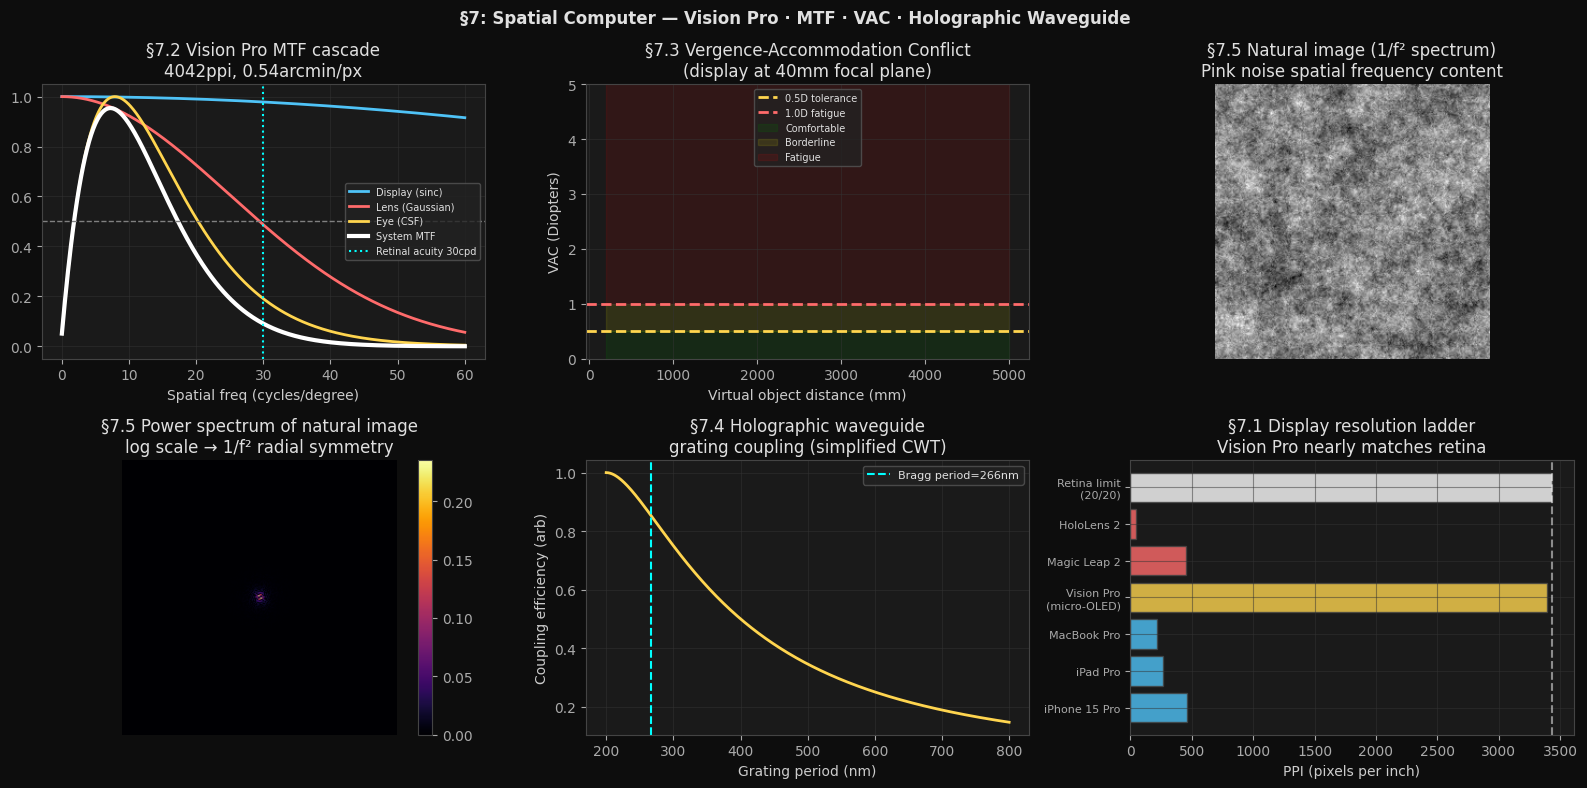


Brain melt complete. e^{jwt} connects everything here too.


In [9]:
# §7 — Spatial computer: Vision Pro display physics

# §7.1 Display parameters (Apple Vision Pro specs)
H_px, W_px = 3142, 3660   # per eye
panel_w_mm = 1.41*25.4    # 1.41 inch diagonal → approx width ~26mm
# Actual Vision Pro: ~23mm wide panel
panel_w_mm = 23.0
ppi_vp     = W_px / (panel_w_mm/25.4)
px_um      = 25400/ppi_vp
view_dist_mm= 40.0   # virtual display distance (eyebox to lenslet)
print(f'§7.1 Vision Pro: {ppi_vp:.0f} ppi, pixel pitch={px_um:.1f} um')

# Angular pixel pitch
arcmin_per_px = np.degrees(np.arctan2(px_um/1000, view_dist_mm))*60
print(f'     {arcmin_per_px:.2f} arcmin/pixel (retina ~1 arcmin, 20/20 vision)')

# §7.2 MTF cascade: lens MTF × display MTF × eye MTF
u_display = np.linspace(0, 60, 400)   # cycles/degree

# Display MTF: sinc (pixel aperture)
# pixel fill factor FF, pitch p: MTF_display = |sinc(FF*u/u_nyq)|
u_nyq     = 60/arcmin_per_px  # Nyquist in cycles/degree
FF        = 0.85   # fill factor
MTF_disp  = np.abs(np.sinc(FF*u_display/(2*u_nyq)))

# Lens MTF (pancake lens array): simplified Gaussian
sigma_lens= 25.0  # cycles/degree (lens resolution)
MTF_lens  = np.exp(-0.5*(u_display/sigma_lens)**2)

# Eye MTF (human CSF as MTF approximation)
# CSF: peak ~6 cpd, rolloff via exponential
def csf_eye(u):
    return 2.6*(0.0192+0.114*u)*np.exp(-(0.114*u)**1.1)
MTF_eye   = csf_eye(u_display+1e-10) / csf_eye(1e-10)
MTF_eye   = np.clip(MTF_eye/MTF_eye.max(),0,1)

MTF_system= MTF_disp * MTF_lens * MTF_eye

# §7.3 Vergence-accommodation conflict
# VAC: display at d_a, virtual object at d_v
d_display_mm = 40.0
d_virtual_arr= np.array([500,750,1000,2000,5000,np.inf])  # mm
VAC_D = np.abs(1000/d_display_mm - 1000/d_virtual_arr)    # Diopters mismatch

print('\n§7.3 VAC (vergence-accommodation conflict):')
for d,vac in zip(d_virtual_arr,VAC_D):
    dist_str = f'{d:.0f}mm' if d!=np.inf else 'inf'
    print(f'  Virtual object at {dist_str:>8s}: VAC = {vac:.2f} D {"<-- tolerable" if vac<0.5 else "<-- fatigue"}')

# §7.4 Holographic waveguide coupling efficiency
# Reflection grating: efficiency via coupled wave theory
lam_disp = 0.532e-6   # 532nm green
n_wvg    = 1.75       # waveguide glass
Lambda_g = np.linspace(200e-9, 800e-9, 400)  # grating period
# Bragg condition: 2*Lambda*sin(theta_B) = lambda
theta_B  = np.arcsin(lam_disp/(2*n_wvg*Lambda_g+1e-20))
valid    = np.isreal(theta_B)&(np.abs(theta_B)<np.pi/2)
eff_coup = np.where(valid, np.sin(np.pi*100e-9/Lambda_g)**2, 0)  # simplified

# §7.5 Spatial frequency of scenes: natural image statistics
# 1/f spectrum: amplitude ∝ 1/f
N_scene = 256
u_scene = np.fft.fftshift(np.fft.fftfreq(N_scene,1.0/N_scene))
v_scene = u_scene.copy()
UU,VV   = np.meshgrid(u_scene,v_scene)
r_scene = np.sqrt(UU**2+VV**2)+0.5
power_1f= 1/(r_scene**2)   # 1/f^2 power spectrum = pink noise image
phase_r = 2*np.pi*np.random.rand(N_scene,N_scene)
img_1f  = np.real(np.fft.ifft2(np.fft.ifftshift(np.sqrt(power_1f)*np.exp(1j*phase_r))))

# ── Plots ─────────────────────────────────────────────────────────
fig,axes = plt.subplots(2,3,figsize=(16,8))
fig.patch.set_facecolor('#0d0d0d')

# MTF cascade
axes[0][0].plot(u_display, MTF_disp,'#4fc3f7',lw=2,label='Display (sinc)')
axes[0][0].plot(u_display, MTF_lens,'#ff6b6b',lw=2,label='Lens (Gaussian)')
axes[0][0].plot(u_display, MTF_eye,'#ffd54f',lw=2,label='Eye (CSF)')
axes[0][0].plot(u_display, MTF_system,'white',lw=3,label='System MTF')
axes[0][0].axvline(30,color='cyan',ls=':',lw=1.5,label='Retinal acuity 30cpd')
axes[0][0].axhline(0.5,color='gray',ls='--',lw=1)
axes[0][0].set_xlabel('Spatial freq (cycles/degree)')
axes[0][0].set_title(f'§7.2 Vision Pro MTF cascade\n{ppi_vp:.0f}ppi, {arcmin_per_px:.2f}arcmin/px')
axes[0][0].legend(fontsize=7,facecolor='#222',edgecolor='#555')

# VAC vs distance
d_v_cont = np.linspace(200,5000,300)
VAC_cont = np.abs(1000/d_display_mm - 1000/d_v_cont)
axes[0][1].plot(d_v_cont,VAC_cont,'#4fc3f7',lw=2)
axes[0][1].axhline(0.5,color='#ffd54f',ls='--',lw=2,label='0.5D tolerance')
axes[0][1].axhline(1.0,color='#ff6b6b',ls='--',lw=2,label='1.0D fatigue')
axes[0][1].fill_between(d_v_cont,0,0.5,alpha=0.15,color='green',label='Comfortable')
axes[0][1].fill_between(d_v_cont,0.5,1.0,alpha=0.1,color='yellow',label='Borderline')
axes[0][1].fill_between(d_v_cont,1.0,VAC_cont.max(),alpha=0.1,color='red',label='Fatigue')
axes[0][1].set_xlabel('Virtual object distance (mm)')
axes[0][1].set_ylabel('VAC (Diopters)')
axes[0][1].set_title('§7.3 Vergence-Accommodation Conflict\n(display at 40mm focal plane)')
axes[0][1].legend(fontsize=7,facecolor='#222',edgecolor='#555')
axes[0][1].set_ylim(0,5)

# Natural image (1/f statistics)
axes[0][2].imshow(img_1f,cmap='gray',origin='lower')
axes[0][2].set_title('§7.5 Natural image (1/f² spectrum)\nPink noise spatial frequency content')
axes[0][2].axis('off')

# Power spectrum of natural image
PS_img = np.abs(np.fft.fftshift(np.fft.fft2(img_1f)))**2
im_ps = axes[1][0].imshow(np.log1p(PS_img),cmap='inferno',origin='lower')
axes[1][0].set_title('§7.5 Power spectrum of natural image\nlog scale → 1/f² radial symmetry')
axes[1][0].axis('off')
plt.colorbar(im_ps,ax=axes[1][0])

# Holographic grating coupling
axes[1][1].plot(Lambda_g*1e9, eff_coup,'#ffd54f',lw=2)
axes[1][1].axvline(lam_disp*1e9/2,color='cyan',ls='--',lw=1.5,
                    label=f'Bragg period={lam_disp*1e9/2:.0f}nm')
axes[1][1].set_xlabel('Grating period (nm)')
axes[1][1].set_ylabel('Coupling efficiency (arb)')
axes[1][1].set_title('§7.4 Holographic waveguide\ngrating coupling (simplified CWT)')
axes[1][1].legend(fontsize=8,facecolor='#222',edgecolor='#555')

# Display resolution ladder
display_types = {
    'iPhone 15 Pro': 460,
    'iPad Pro':      264,
    'MacBook Pro':   220,
    'Vision Pro\n(micro-OLED)': 3391,
    'Magic Leap 2':  450,
    'HoloLens 2':    47,
    'Retina limit\n(20/20)':   3438,
}
names_d = list(display_types.keys()); ppi_d = list(display_types.values())
colors_d= ['#4fc3f7','#4fc3f7','#4fc3f7','#ffd54f','#ff6b6b','#ff6b6b','white']
axes[1][2].barh(range(len(names_d)),ppi_d,color=colors_d,alpha=0.8,edgecolor='#444')
axes[1][2].set_yticks(range(len(names_d)))
axes[1][2].set_yticklabels(names_d,fontsize=8)
axes[1][2].set_xlabel('PPI (pixels per inch)')
axes[1][2].set_title('§7.1 Display resolution ladder\nVision Pro nearly matches retina')
axes[1][2].axvline(3438,color='white',ls='--',lw=1.5,alpha=0.5)
plt.suptitle('§7: Spatial Computer — Vision Pro · MTF · VAC · Holographic Waveguide',
             fontsize=12,fontweight='bold',color='#e0e0e0')
plt.tight_layout(); plt.show()
print('\nBrain melt complete. e^{jwt} connects everything here too.')